# Задача бинарной классификации 

### Целевая метрика: F1-macro

Датасет **Adult Census Income**. Датасет содержит информацию о взрослых и используется для предсказания, зарабатывает ли человек больше или меньше 50,000 долларов в год. Описание колонок:
- `age` - возраст человека
- `workclass` - тип занятости (например, частный сектор, государственная служба, собственный бизнес и т.д.)
- `fnlwgt` - финальный вес (final weight) — это взвешенное значение, которое используется для представления выборки населения в исследованиях
- `education` - уровень образования (например, среднее образование, бакалавр и т.д.)
- `education_num` - числовое представление уровня образования (например, 10 для среднего образования, 13 для бакалавра и т.д.).
- `marital.status` - семейное положение (например, женат/замужем, разведён, вдовец и т.д.)
- `occupation` - род занятий (например, инженер, врач, работник сферы обслуживания и т.д.)
- `relationship` - отношение к главе семьи (например, муж, жена, не состоящий в браке и т.д.)
- `race` - раса человека (например, белый, черный, азиат и т.д.)
- `sex` - пол человека (мужской или женский)
- `capital.gain` - прибыль от капитала — доход от продажи активов
- `capital.loss` - убыток от капитала — убыток от продажи активов
- `hours.per.week` - количество рабочих часов в неделю
- `native.country` - срана происхождения (например, США, Канада и т.д.)
- `income` - целевая переменная - доход выше или ниже 50,000 долларов в год (значения: <=50K или >50K)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('adult.csv')

## 1. Первичный анализ данных

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


In [4]:
data.head(5)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 2. Анализ целевой переменной

In [5]:
data['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Колонка-таргет 'income' содержит два значения: '<=50K' и '>50K'. Для бинарной классификации, нам удобнее будет использовать метки 0 и 1 соответственно

In [6]:
target = data['income']

In [7]:
pd.DataFrame({
    'count':   target.value_counts(),
    'percent': target.value_counts(normalize=True),
})

,count,percent
income,,
<=50K,24720,0.75919
>50K,7841,0.24081


Есть перекос классов, соотношение примерно 3 к 1. Это стоит учитывать

## 3. Анализ качества данных
### 3.1 Пропущенные значения

In [8]:
data.isin(['?']).sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

В данных есть пропуски, они обозначаются '?', заменим их на NaN

In [9]:
eda_data = data.copy()
eda_data.replace('?', np.nan, inplace=True)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


Проанализиурем пропуски в данных:

In [10]:
eda_data.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

В колонках workclass и occupation практиччески одинаковое количество пропусков, возможно это одни и те же строки, проверим это:

In [11]:
both = eda_data[eda_data['workclass'].isna() & eda_data['occupation'].isna()]

In [12]:
len(both)

1836

Предположение подтвердилось, все строки с пропусками в workclass также имеют пропуск в occupation

Посмотрим отдельно на строки с пропускми в 'workclass'/'occupation' и 'native.country'

In [13]:
occupation_gap = eda_data[eda_data['occupation'].isna()]
country_gap = eda_data[eda_data['native.country'].isna()]

In [14]:
occupation_gap['income'].value_counts(normalize=True)

income
<=50K    0.896365
>50K     0.103635
Name: proportion, dtype: float64

In [15]:
occupation_gap[occupation_gap['income'] == 1].head(3)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income


In [16]:
country_gap['income'].value_counts(normalize=True)

income
<=50K    0.749571
>50K     0.250429
Name: proportion, dtype: float64

Абсолютное большинство тех о ком неизвестно ничего про род деятельности не зарабатывают больше 50k в год. Чего не скажешь о строках с пропусками в родной стране, хоть перекос и есть, но 25 процентов уже выглядит солидно.

### Инсайт
Пропуски в колонках occupation/workclass понятные. Заполнять не нужно, потому что они несут в себе информацию о том что человек нигде не работает. можем дать им отдельную категорию, например 'Unknown'.
Cледовательно, большинство из них абсолютно закономерно зарабатывают меньше 50k в год. 10 процентов - это видимо богатые люди, которым и работать не нужно.

## 4. Анализ признаков

### 4.1 Анализ числовых признаков

У нас есть 2 вида признако: числовые и категориальные. Разделим их и проанализируем по отдельности

In [17]:
num_cols = eda_data.select_dtypes(include='number').columns.to_list()
cat_cols = eda_data.select_dtypes(exclude='number').columns.to_list()
cat_cols.remove('income')

In [18]:
num_cols

['age',
 'fnlwgt',
 'education.num',
 'capital.gain',
 'capital.loss',
 'hours.per.week']

In [19]:
len(num_cols) + len(cat_cols) == len(eda_data.columns) # проверка, что ничего не потеряли

False

#### Анализ числовых признаков

In [20]:
num_cols

['age',
 'fnlwgt',
 'education.num',
 'capital.gain',
 'capital.loss',
 'hours.per.week']

In [21]:
eda_data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


Рассмотрим частотные графики числовых признаков

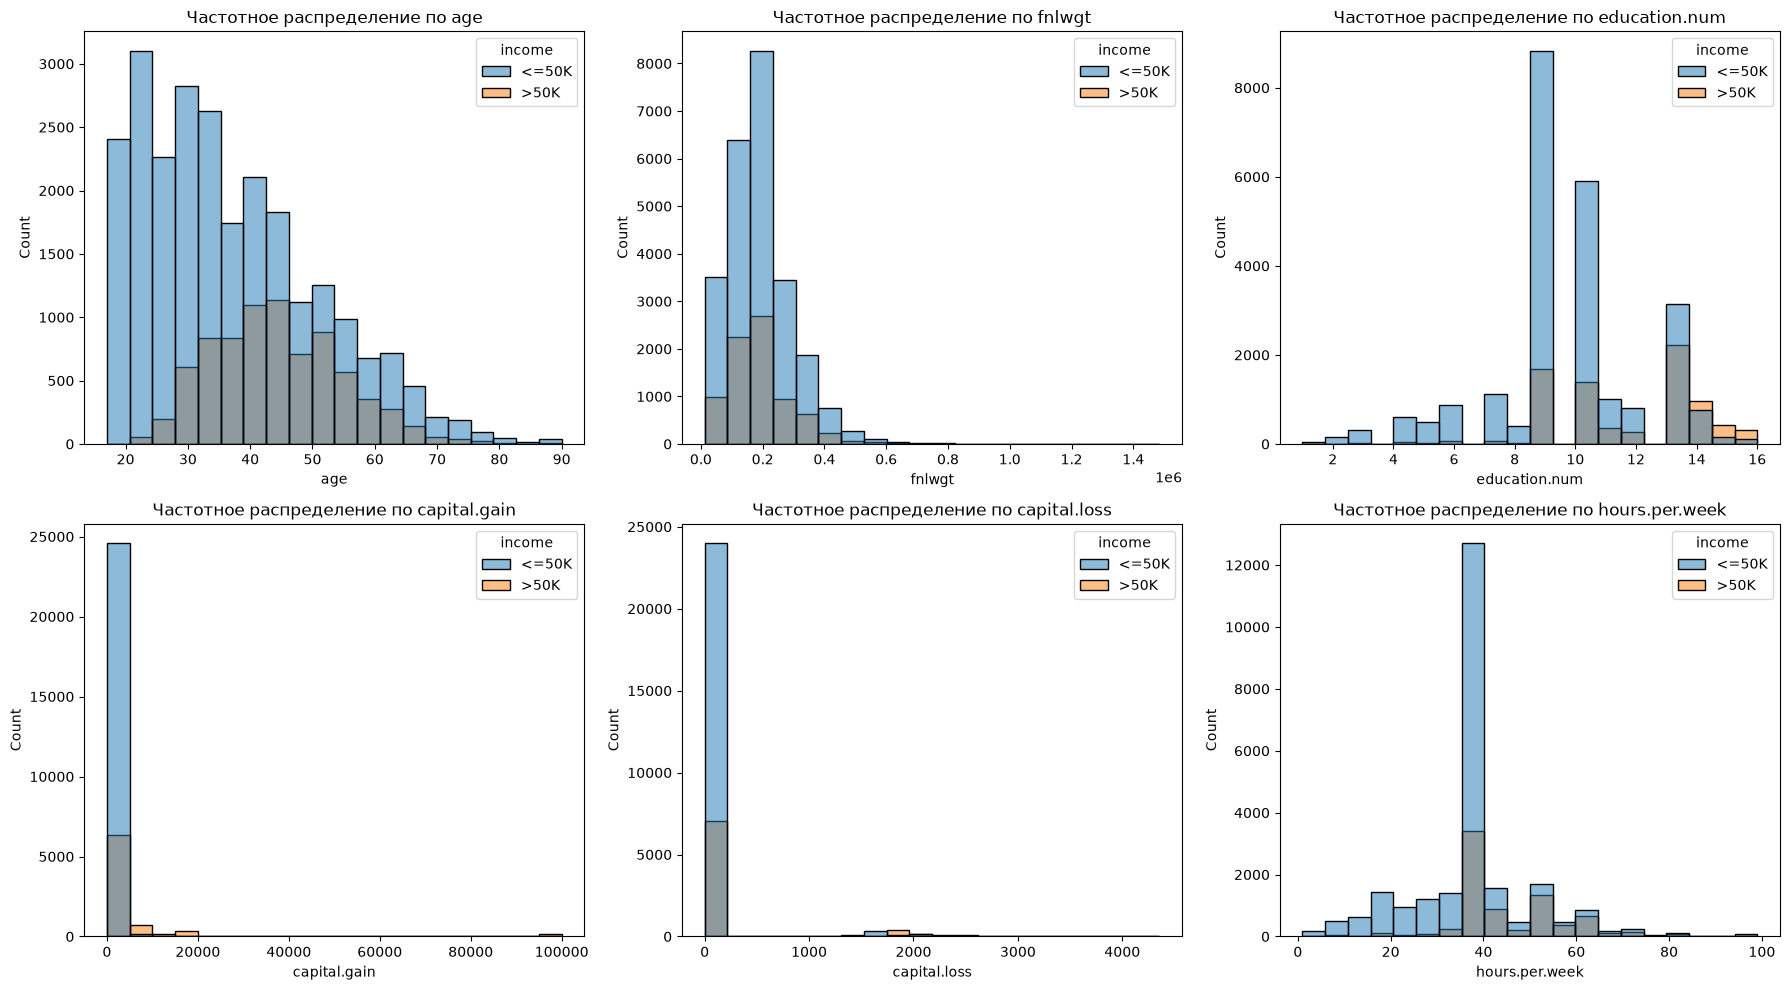

In [22]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(eda_data, x=col, ax=axes[i], bins=20, palette='tab10', hue='income')
    axes[i].set_title(f'Частотное распределение по {col}')

plt.tight_layout()
plt.show()

Из графиков видно следующее:
- Абсолютное большинство не продаёт и не покупает активы, поэтому у них 0 в соответствующих признаках capital.gain и capital.loss
- Абсолютное большинство работает по 40 часов в неделю, и кроме того можно видеть, что чем больше часов работает человек, тем больше там процент тех кто зарабатывает больше 50K и наоборот.
- На заработок влияет степень образования
- График частотного распределения по годам для тех, кто зарабатывает больше 50K достаточно симметричный и куполобразный, похож на нормально распределение с центром около 40-50 лет

Проверим действительно ли возраст людей с зароботком больше 50K является нормальным (или примерно нормальным) распределением

In [23]:
ages_of_riches = eda_data['age'][target == '>50K']

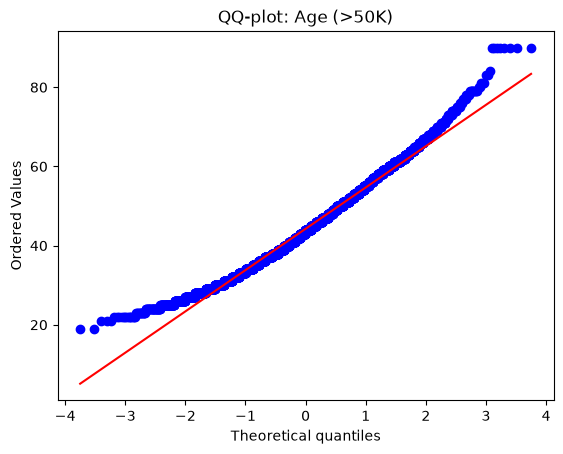

In [24]:
from scipy import stats

stats.probplot(ages_of_riches, plot=plt)
plt.title('QQ-plot: Age (>50K)')
plt.show()

Хоть в центральной части графика точки хорошо ложаться на прямую, на краях видны достаточно сильные отклонения. Так что сказать, что этот признак распределён нормально нельзя.

Теперь рассмотрим boxplot графики для числовых признаков, кроме capital.gain, capital.loss (для них график ничего не даст, там почти все значения 0) и education.num (оно дискретное (1-16) и boxplot по нему не очень пригодится):

In [25]:
num_cols_vrem = num_cols[:]
num_cols_vrem.remove('capital.gain')
num_cols_vrem.remove('capital.loss')
num_cols_vrem.remove('education.num')

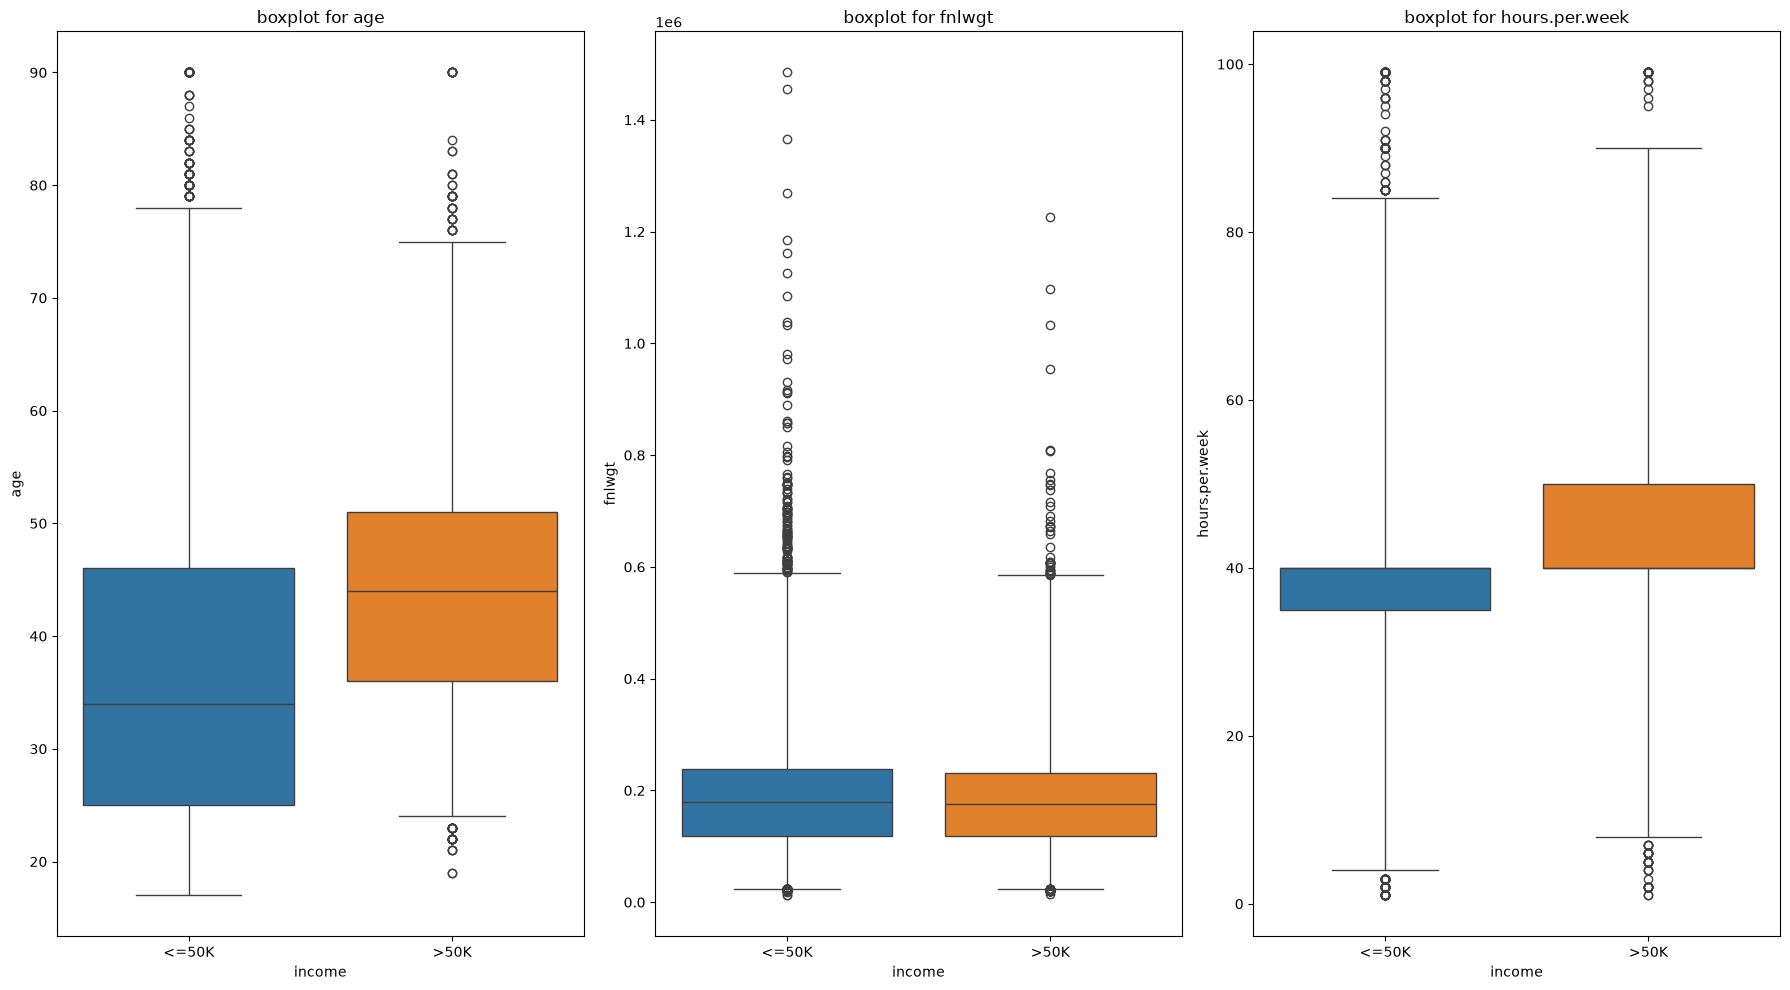

In [26]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols_vrem):
    sns.boxplot(data=eda_data, ax=axes[i], x='income', y=col, hue='income', palette='tab10', whis=(0.5, 99.5))
    axes[i].set_title(f'boxplot for {col}')

plt.tight_layout()
plt.show()

Выводы из графиков:
- признак fnlwgt распределён практически одинаково п оотношению к обоим классам
- у признака age разная медиана для двух этих классов income, для тех кто зарабатывает больше 50K медиана ~ 45, для тех кто меньше ~35. Разница около 10 лет.
- у признака hours.per.week ситация схожа с age, медиана среди людей зарабатывающих больше 50K выше примерно на 10 часов.

### 4.2 связь числовых признаков с target

In [27]:
target_numeric = eda_data['income'].map({'<=50K': 0, '>50K': 1})

target_corr = eda_data[num_cols].corrwith(target_numeric)
target_corr.sort_values(ascending=False)

education.num     0.335154
age               0.234037
hours.per.week    0.229689
capital.gain      0.223329
capital.loss      0.150526
fnlwgt           -0.009463
dtype: float64

Наибольшую корреляцию с target показывает education.num, но недостаточно, для чтобы считать, что найдена линейная связь.

### 4.3 Взаимосвязь числовых признаков

Проверим нет ли мультиколлинеарности среди числовых признаков

<Axes: >

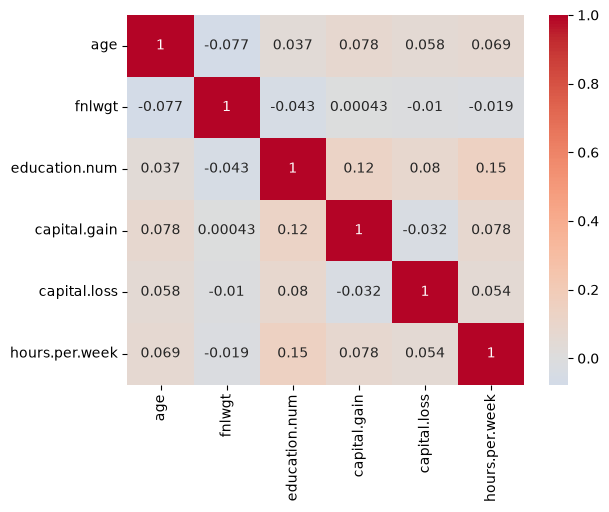

In [28]:
sns.heatmap(eda_data[num_cols].corr(numeric_only=True), cmap='coolwarm', center=0, annot=True)

Все значения очень малы, следовательно мультиколинеарности числовых признаков нет

## 5. Анализ категориальных признаков

### 5.1 Распределения категориальных признаков

In [29]:
cat_cols

['workclass',
 'education',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native.country']

Рассмотрим графики частотного распределения для категориальных признаков

In [30]:
eda_data.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


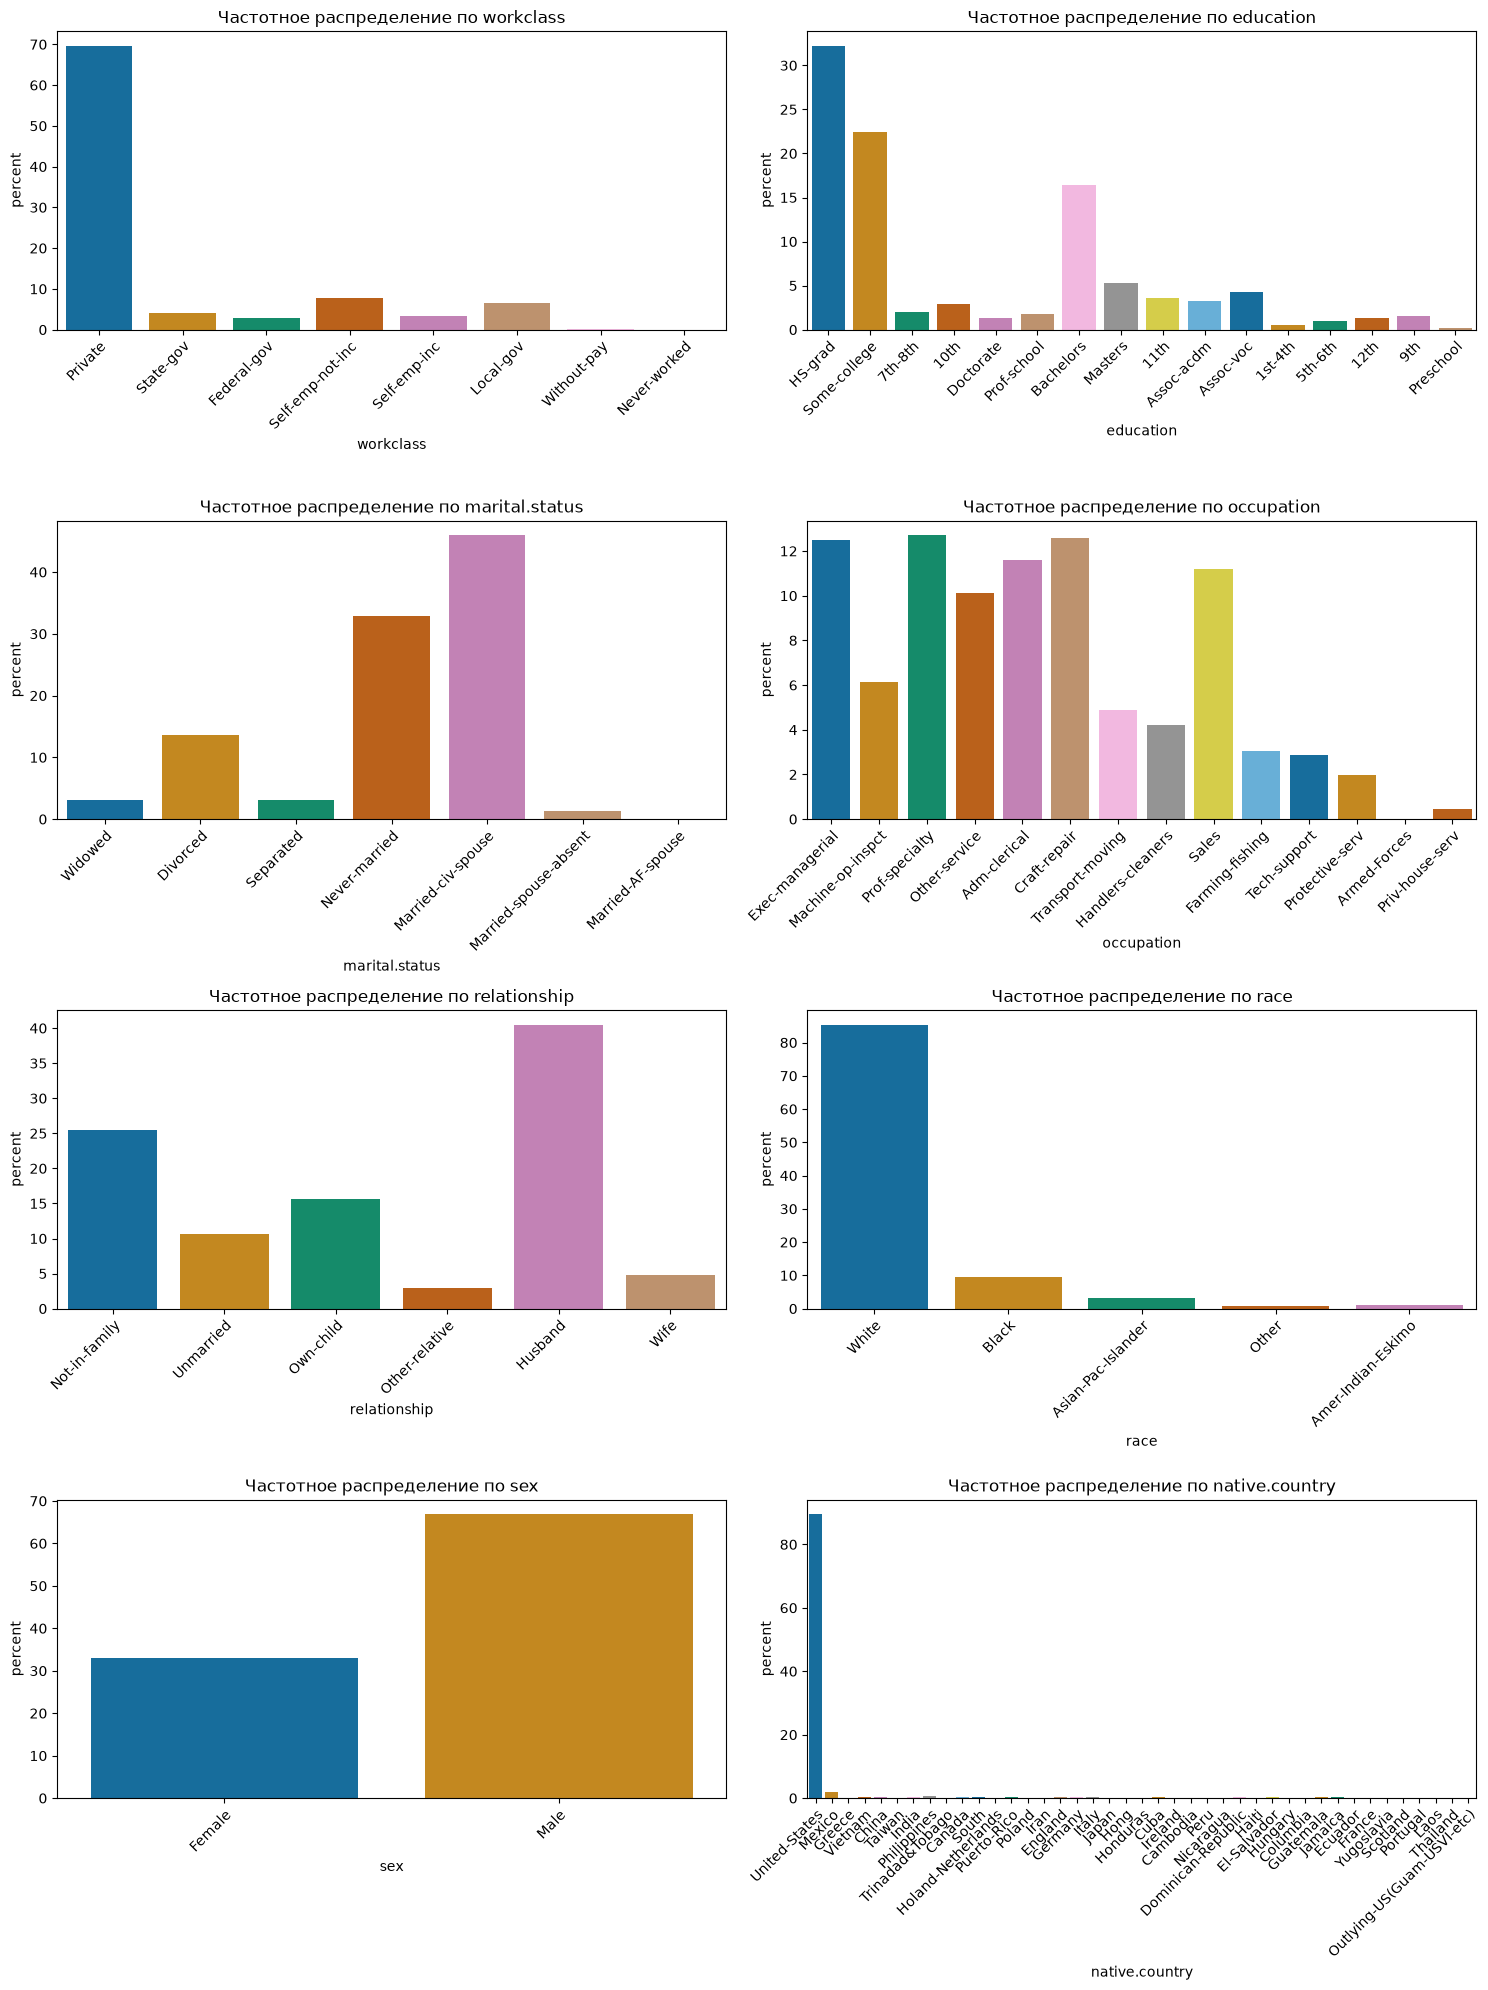

In [31]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(eda_data, x=col, ax=axes[i], palette='colorblind', hue=col, stat='percent')
    axes[i].set_title(f'Частотное распределение по {col}')
    plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

plt.tight_layout()
plt.show()

Из графиков можно сделать следующие выводы:
- Мужчин примерно в 2 раза больше чем женщин (65% vs 35%)
- Подавляющее большинство (>80%) родом из США. На все остальные страны в сумме приходится менее 20%, при этом доля каждой отдельной страны не превышает 1%
- Абсолютное большинство (>80%) являются белыми, на втором месте афроамериканцы (~10%), Суммарная доля представителей других рас составляет менее 5%
- Абсолютное большинство людей (~70%) работают в частном секторе (Private в признаке workclass) и почти нет людей (суммарно менее 1%), которые никогда не работали и без зарплаты
- Большинство (~30%) людей закончили только старшую школу, на втором месте по популярности (~23%) те, кто закончил колледж, на третьем с небольшим отставанием (~18%) бакалавриат, остальные варианты имеют значительно меньшие показатели
- Большинство людей состоят в браке (~45%) или никогда не были женаты (~30%), что в сумме составляет ~75% выборки

### 5.2 Связь категориальных признаков с target

Теперь рассмотрим те же частотные графики для категориальных признаков, но с разделением для классов таргета

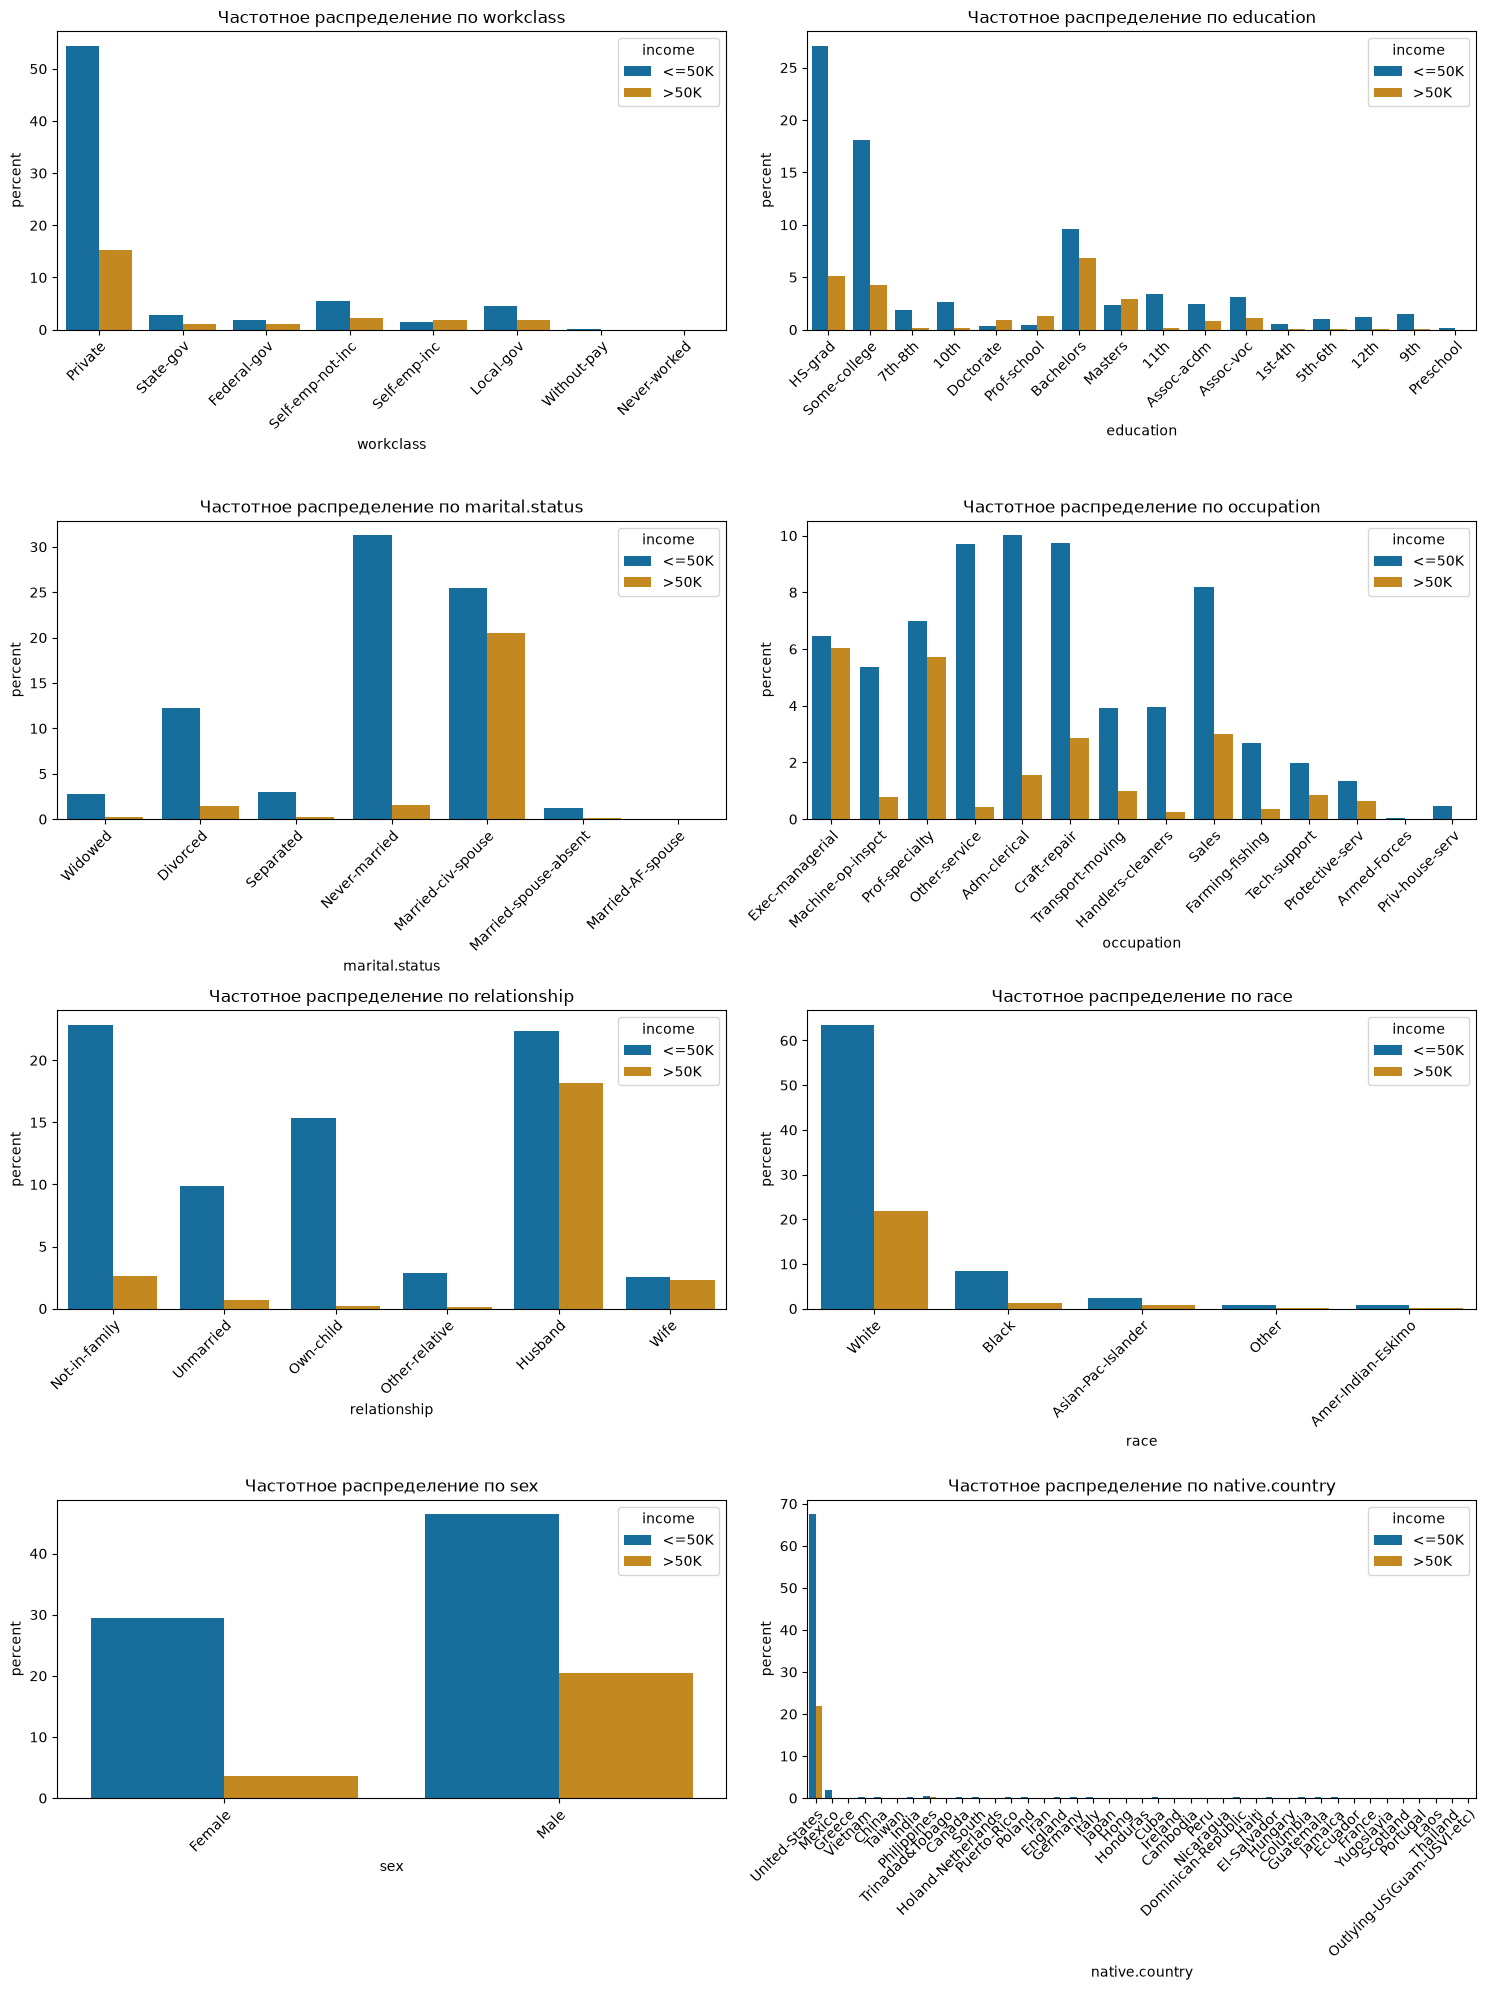

In [32]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(eda_data, x=col, ax=axes[i], palette='colorblind', hue='income', stat='percent')
    axes[i].set_title(f'Частотное распределение по {col}')
    plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

plt.tight_layout()
plt.show()

Из этих графиков можно заметить следующее:
- Для признака education количество людей, зарабатывающих >50K в процентном соотношении к количеству людей в этой группе растёт следующим образом: high-school < college < bachelor < master < doctor < prof-school. Начиная с master преобладает кол-во людей с target=1.
- Абсолютное большинство, зарабатывающих больше 50K (~20% от всех людей) состоят в браке. А в категории never-married наоборот, несмотря на большое количество людей, зарабатывают больше 50K лишь 2-3%
- В категориях Exec-managerial и prof-speciality практически равное количество людей в обоих классах таргета. В категории other-service, наоборот отношение, зарабатывающих меньше 50K к зарабатывающим больше 50K равно ~0.5% vs ~10%
- Среди женщин, зарабатывающих >50K намного меньше, чем других: 3% vs 30%, а у мужчин показатели намного лучше: 20% vs 45%

### 5.3 Анализ `native.country`

In [ ]:
eda_data['native.country'].value_counts(normalize=True).to_frame().reset_index()

Как мы уже поняли ранее ~90% выборки родом из USA, на остальные 41 приходится всего ~10%, а на каждую в отдельности не больше 2%. При дальгейшем one-hot кодировании этого признака будет создано 42 колонки, что очень много. Чтобы предотвратить это и не сильно потерять информацию, я предлагаю модифицировать этот признак в блоке предобработке данных.

## 6. Анализ взаимосвязей между признаками

Теперь посмотрим на корреляцию среди всех признаков. Построим матрицу корреляции для них.

In [33]:
# pip install phik

In [34]:
import phik
corr = eda_data.phik_matrix()

interval columns not set, guessing: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']


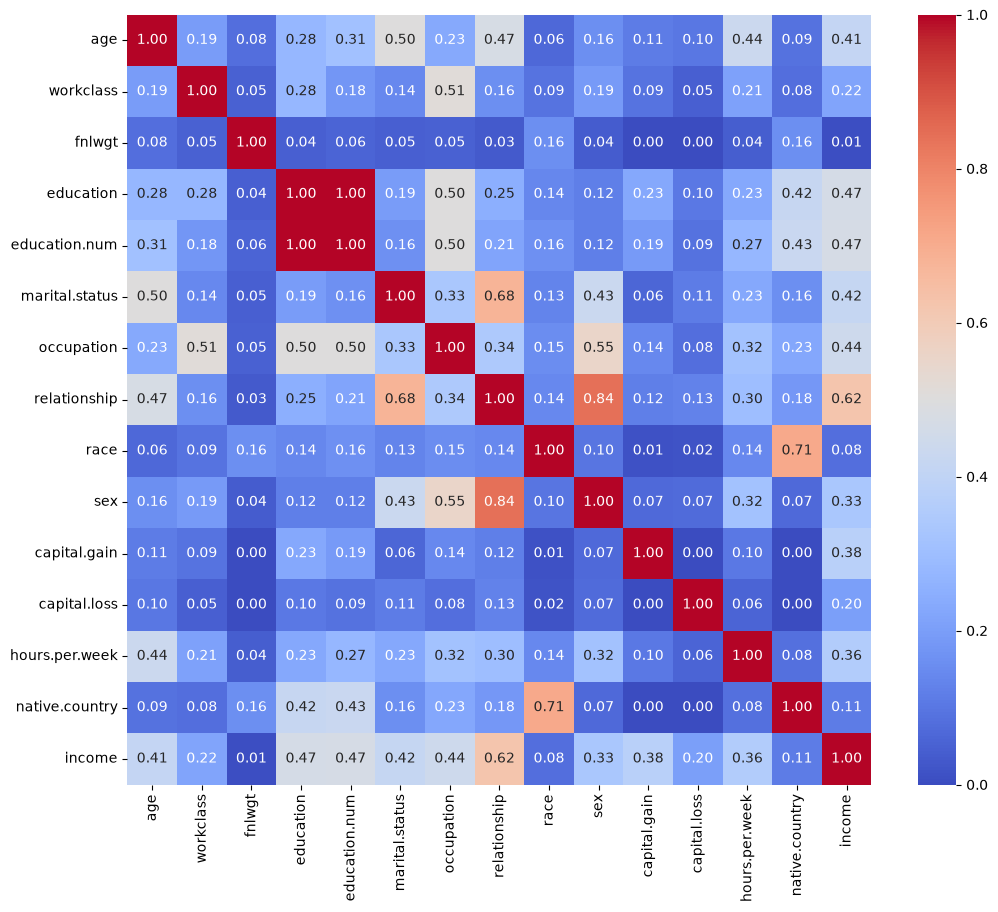

In [35]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=0, vmax=1)
plt.show()

В этой матрице корреляции можно заметить следующие особенности:
- education и education.num абсолютно идентичны (корреляция 1.0), один из этих признаков обязательно нужно убрать. Оставим education.num
- признаки sex и relationship имебт высокую корреляцию (0.84)
- occupation и workclass также достаточно сильно скоррелированы (0.73)
- признак fnlwgt имеет крайне малую корреляцию с таргетом (0.01). Со всеми остальными признаками у него тоже очень малая корреляция. Можно сделать вывод, что fnlwgt никак не описывает человека и его доход. Его можно смело удалять
- признаки relationship и marital.status имеют высокую корреляцию (0.68)
- признаки native.country и race сильно скоррелированы (0.69), как уже говорилось ранее, скорее всего native.country будет модифицирован

# 7. Итоги EDA

### 7.1 Решения для preprocessing

| Наблюдение | Решение|
| --- | --- |
| В `workclass`, `occupation`, `native.country` есть пропуски (в первых двух пропуски совпадают) | Заменить пропуски на `Unknown`|
| `education` и `education.num` полностью дублируют друг друга | Оставить `education.num`, удалить `education|
| `native.country` сильно несбалансирован по категориям        | Переделать его в признак `is_usa`|
| `fnlwgt` не показывает связи с target               | удалить признак из данных |
| target (`income`) несбалансирован по классам, отношение примерно 3 к 1 в пользу '<=50K'      | Учитывать это при обучении моделей и разделении данных на test и train|

### 7.2 Выводы EDA

1. данные содержат и числовые, и категориальные признаки.
2. Линейная связь числовых признаков и таргета слабая.
2. Численные признаки достаточно зашумлённые, видно на boxplot графиках.
3. Пропуски в данных есть но их немного, только в колонках workclass ~ occupation ~ 1800 и native.country ~ 500.
4. Разный масштаб числовых признаков.
5. Модели стоит обучать и оценивать с учётом дисбаланса классов.